In [1]:
from word_play.run import run_sim
from word_play.agent import Constant_Strategy_Agent, Explicit_Belief_Agent, Random_Agent
from word_play.environment import Action, ActOpt, Harvest
from word_play.model import Human, ChatGPT

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

/tmp/ipykernel_16442/3521229318.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
agents = [
	#Constant_Strategy_Agent(Action(ActOpt.apple, ActOpt.banana)),
	#Constant_Strategy_Agent(Action(ActOpt.banana, ActOpt.apple))
	#Explicit_Belief_Agent(Human()),
	Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
]
env = Harvest(agents=agents)
step_count = 3

action_history, reward_history, expectation_history, cot_history = run_sim(env=env, step_count=step_count)

steps:  67%|██████▋   | 2/3 [00:32<00:16, 16.96s/it]

invalid format on attempt: 0
exception: bad input_str: ("banana, apple"


steps: 100%|██████████| 3/3 [00:57<00:00, 19.10s/it]


In [8]:
for step in range(step_count):
	print('==================================================')
	print('Step:', step)
	print('==================================================')
	print('Actions:')
	for agent_id in range(env.agent_count):
		print('agent_id:', agent_id)
		print('harvest:', action_history[step][agent_id].harvest.name)
		print('sanction:', action_history[step][agent_id].sanction.name)
	print('-------------')
	print('Rewards:')
	for agent_id in range(env.agent_count):
		print(f'agent_id: {agent_id}, reward:', reward_history[step][agent_id])
	print('-------------')
	print('Expectations:')
	for agent_id in range(env.agent_count):
		print('agent_id:', agent_id)
		print('expectations:', expectation_history[step][agent_id])
	print('-------------')
	print('Selection CoT:')
	for agent_id in range(env.agent_count):
		print('agent_id:', agent_id)
		print('CoT:', cot_history[step][agent_id])

Step: 0
Actions:
agent_id: 0
harvest: apple
sanction: banana
agent_id: 1
harvest: apple
sanction: banana
-------------
Rewards:
agent_id: 0, reward: 10
agent_id: 1, reward: 10
-------------
Expectations:
agent_id: 0
expectations: {
  "consumption": "Apple",
  "sanction": "Banana"
}
agent_id: 1
expectations: {"consumption": "Apple", "sanction": "Banana"}
-------------
Selection CoT:
agent_id: 0
CoT: 1. Since this is the first round and I have no prior information about the opponent's strategy, I will start by choosing a safe and common consumption card - Apple. This card has the potential to give a moderate amount of points and is a simple choice.

2. For the sanction card, my goal is to strategically select a card that can impact the opponent's strategy while maximizing my own points. Considering the available options (Apple, Banana, Apple + Banana, Empty), I will choose Banana as the sanction card. This card allows me to potentially sanction the opponent's Apple consumption card, redu

/h/andrei/anaconda3/envs/word_play/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/h/andrei/anaconda3/envs/word_play/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


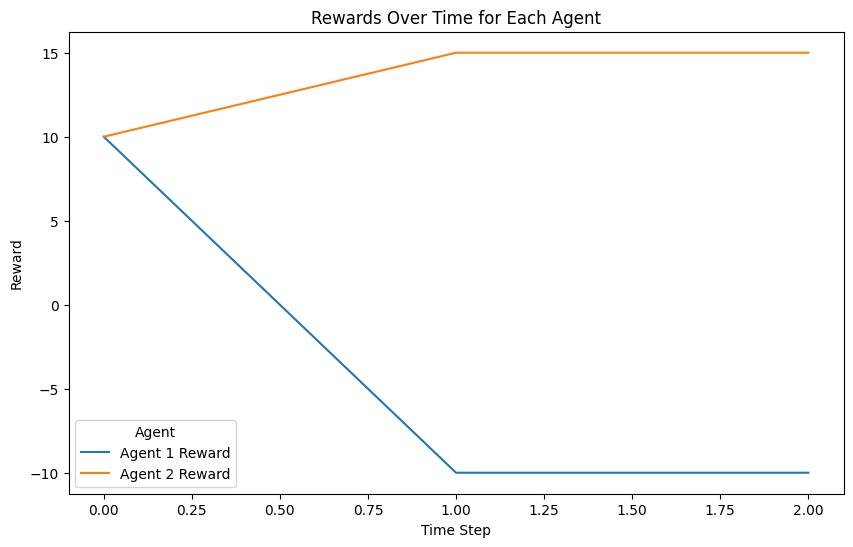

In [11]:
# Convert reward_history to a pandas DataFrame
df = pd.DataFrame(reward_history, columns=['Agent 1 Reward', 'Agent 2 Reward'])
df['Time Step'] = df.index

# Melting the DataFrame for use with Seaborn
df_melted = df.melt(id_vars=['Time Step'], var_name='Agent', value_name='Reward')

# Plotting with Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Time Step', y='Reward', hue='Agent')
plt.title('Rewards Over Time for Each Agent')
plt.xlabel('Time Step')
plt.ylabel('Reward')
plt.legend(title='Agent')
plt.show()

# GPT 3.5 vs GPT 3.5

In [15]:
agents = [
	#Constant_Strategy_Agent(Action(ActOpt.apple, ActOpt.banana)),
	#Constant_Strategy_Agent(Action(ActOpt.banana, ActOpt.apple))
	#Explicit_Belief_Agent(Human()),
	Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
]
env = Harvest(agents=agents)
step_count = 25
repeat_count = 5

action_histories = []
reward_histories = []
expectation_histories = []
cot_histories = []
for repeat in tqdm(range(repeat_count), desc='repeats'):
	action_history, reward_history, expectation_history, cot_history = run_sim(env=env, step_count=step_count)
	action_histories.append(action_history)
	reward_histories.append(reward_history)
	expectation_histories.append(expectation_history)
	cot_histories.append(cot_history)

repeats:   0%|          | 0/5 [00:00<?, ?it/s]

agents:   0%|          | 0/2 [00:00<?, ?it/s]

invalid format on attempt: 0
exception: bad input_str: ("Apple, Empty"



agents: 100%|██████████| 2/2 [00:22<00:00, 11.26s/it]



agents: 100%|██████████| 2/2 [00:17<00:00,  8.83s/it]



agents: 100%|██████████| 2/2 [00:13<00:00,  6.89s/it]




invalid format on attempt: 0
exception: String: " apple + banana" does not correspond to a valid ActOpt Enum value



agents: 100%|██████████| 2/2 [00:19<00:00,  9.84s/it]



agents: 100%|██████████| 2/2 [00:20<00:00, 10.20s/it]




...

invalid format on attempt: 0
exception: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens. However, your messages resulted in 4140 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
invalid format on attempt: 1
exception: String: ""Empty"" does not correspond to a valid ActOpt Enum value
invalid format on attempt: 2
exception: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens. However, your messages resulted in 4142 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
invalid format on attempt: 3
exception: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens. However, your messages resulted in 4182 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'para

invalid format on attempt: 0
exception: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens. However, your messages resulted in 4182 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}


repeats:  60%|██████    | 3/5 [22:18<14:52, 446.28s/it]

invalid format on attempt: 1
exception: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens. However, your messages resulted in 4182 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}


KeyboardInterrupt: 

In [19]:
print(step)

2


In [4]:
def plot_avg_reward(reward_histories):
	# Calculating the average reward at each time step for all samples
	avg_rewards = [np.mean(sample, axis=1) for sample in reward_histories]

	# Creating a DataFrame from the average rewards
	df_avg = pd.DataFrame(avg_rewards).T  # Transpose to get time steps as rows
	df_avg['Time Step'] = df_avg.index

	# Calculating mean and standard deviation across samples
	df_avg['Mean Reward'] = df_avg.mean(axis=1)
	df_avg['Std Reward'] = df_avg.std(axis=1)

	# Plotting with Seaborn
	plt.figure(figsize=(10, 6))
	sns.lineplot(data=df_avg, x='Time Step', y='Mean Reward', label='Mean Reward')
	plt.fill_between(df_avg['Time Step'], df_avg['Mean Reward'] - df_avg['Std Reward'], 
					df_avg['Mean Reward'] + df_avg['Std Reward'], alpha=0.3)
	plt.title('Average Reward Over Time (Across All Agents and Samples)')
	plt.xlabel('Time Step')
	plt.ylabel('Average Reward')
	plt.legend()
	plt.show()

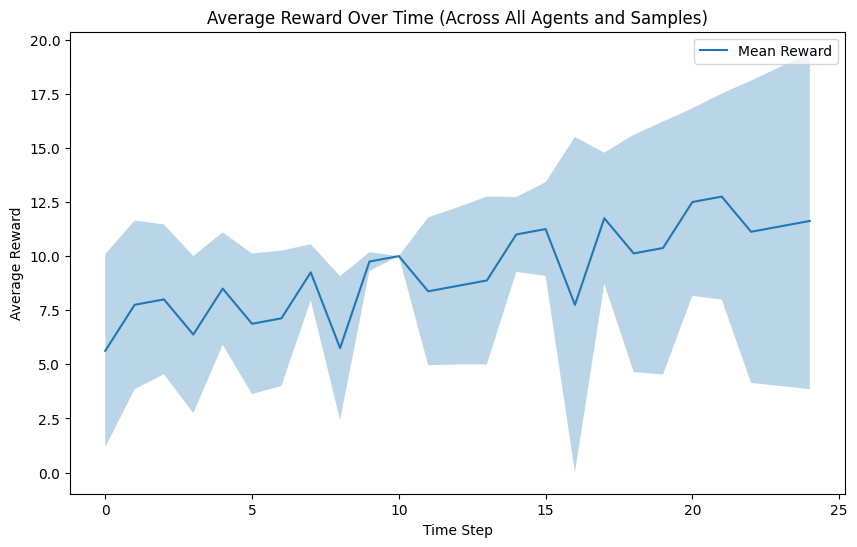

In [21]:
plot_avg_reward(reward_histories)

# Random vs Random

In [3]:
agents = [
	#Constant_Strategy_Agent(Action(ActOpt.apple, ActOpt.banana)),
	#Constant_Strategy_Agent(Action(ActOpt.banana, ActOpt.apple))
	#Explicit_Belief_Agent(Human()),
	#Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	#Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Random_Agent(),
	Random_Agent(),
]
env = Harvest(agents=agents)
step_count = 25
repeat_count = 5

random_vs_random_reward_histories = []
for repeat in tqdm(range(repeat_count), desc='repeats'):
	action_history, reward_history, expectation_history, cot_history = run_sim(env=env, step_count=step_count)
	random_vs_random_reward_histories.append(reward_history)

agents: 100%|██████████| 2/2 [00:00<00:00, 9927.35it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 11966.63it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13640.01it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 12122.27it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13421.77it/s]


agents:   0%|          | 0/2 [00:00<?, ?it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 8208.03it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 10810.06it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13148.29it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13595.80it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 14364.05it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15797.76it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15169.27it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15709.00it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15887.52it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 11634.69it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15335.66it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13934.56it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 9962.72it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 12018.06it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 10046.24it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 11586.48it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 13842.59it/s]

agents: 100%|███

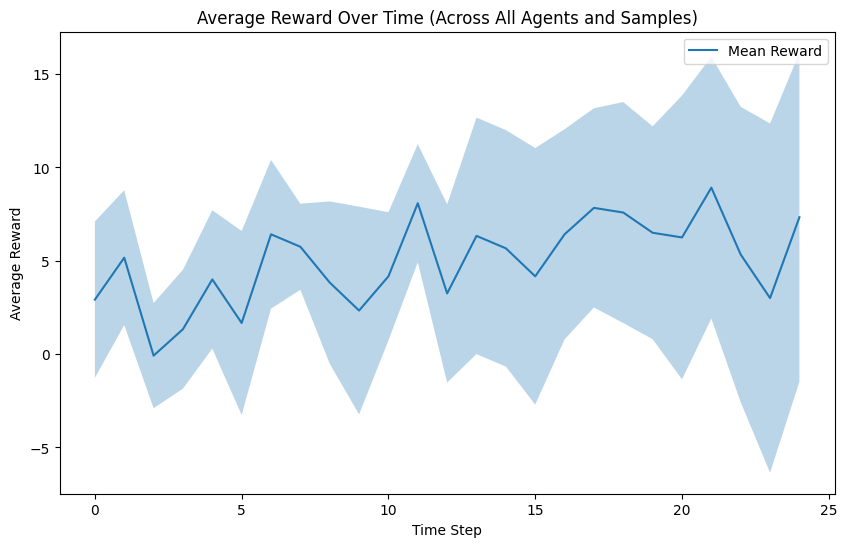

In [4]:
plot_avg_reward(random_vs_random_reward_histories)

# Random vs Constant (banana, apple)

In [5]:
agents = [
	#Constant_Strategy_Agent(Action(ActOpt.apple, ActOpt.banana)),
	Constant_Strategy_Agent(Action(ActOpt.banana, ActOpt.apple)),
	#Explicit_Belief_Agent(Human()),
	#Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	#Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Random_Agent(),
	#Random_Agent(),
]
env = Harvest(agents=agents)
step_count = 25
repeat_count = 5

random_vs_ba_reward_histories = []
for repeat in tqdm(range(repeat_count), desc='repeats'):
	action_history, reward_history, expectation_history, cot_history = run_sim(env=env, step_count=step_count)
	random_vs_ba_reward_histories.append(reward_history)

agents: 100%|██████████| 2/2 [00:00<00:00, 12000.87it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 14588.88it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 17734.90it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15709.00it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16777.22it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15087.42it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 17331.83it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15978.30it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 15827.56it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16644.06it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16644.06it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16677.15it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 17623.13it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 10131.17it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16946.68it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 17476.27it/s]

agents: 100%|██████████| 2/2 [00:00<00:00, 16070.13it/s]

agents: 100%|█

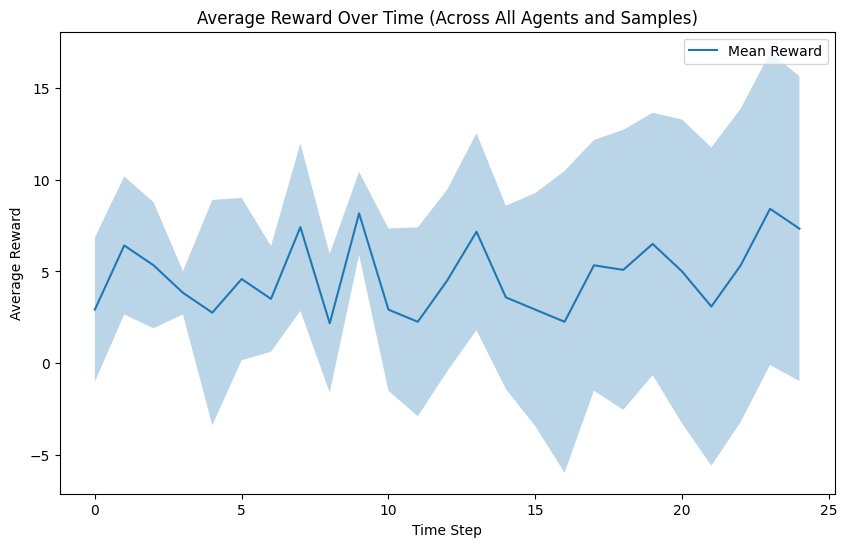

In [6]:
plot_avg_reward(random_vs_ba_reward_histories)

# GPT 3.5 vs Random

# GPT 3.5 vs Constant (banana, apple)

In [5]:
agents = [
	#Constant_Strategy_Agent(Action(ActOpt.apple, ActOpt.banana)),
	#Constant_Strategy_Agent(Action(ActOpt.banana, ActOpt.apple))
	#Explicit_Belief_Agent(Human()),
	#Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Explicit_Belief_Agent(ChatGPT('gpt-3.5-turbo', 'You are a strategic game playing agent.', verbosity=1)),
	Random_Agent(),
	#Random_Agent(),
]
env = Harvest(agents=agents)
step_count = 10
repeat_count = 5

gpt3_vs_random_reward_histories = []
for repeat in tqdm(range(repeat_count), desc='repeats'):
	action_history, reward_history, expectation_history, cot_history = run_sim(env=env, step_count=step_count)
	gpt3_vs_random_reward_histories.append(reward_history)

repeats:   0%|          | 0/5 [00:00<?, ?it/s]



agents: 100%|██████████| 2/2 [00:07<00:00,  3.89s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.70s/it]


agents: 100%|██████████| 2/2 [00:06<00:00,  3.27s/it]



invalid format on attempt: 0
exception: String: "empty" does not correspond to a valid ActOpt Enum value



agents: 100%|██████████| 2/2 [00:20<00:00, 10.39s/it]



invalid format on attempt: 0
exception: String: " apple + banana" does not correspond to a valid ActOpt Enum value


...


agents: 100%|██████████| 2/2 [00:28<00:00, 14.44s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.81s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.89s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.99s/it]


agents: 100%|██████████| 2/2 [00:08<00:00,  4.15s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.69s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.85s/it]


agents: 100%|██████████| 2/2 [00:10<00:00,  5.16s/it]


agents: 100%|██████████| 2/2 [00:04<00:00,  2.36s/it]


repeats:  40%|████      | 2/5 [03:21<04:57, 99.04s/it] 

agents: 100%|██████████| 2/2 [00:05<00:00,  2.84s/it]


agents: 100%|██████████| 2/2 [00:04<00:00,  2.13s/it]


agents: 100%|██████████| 2/2 [00:10<00:00,  5.08s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.73s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.52s/it]



invalid format on attempt: 0
exception: String: ""Apple+Banana"" does not correspond to a valid ActOpt Enum value



agents: 100%|██████████| 2/2 [00:14<00:00,  7.22s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.74s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.61s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.88s/it]


repeats:  60%|██████    | 3/5 [05:00<03:18, 99.17s/it]

agents: 100%|██████████| 2/2 [00:05<00:00,  2.86s/it]


agents: 100%|██████████| 2/2 [00:08<00:00,  4.42s/it]


agents: 100%|██████████| 2/2 [00:06<00:00,  3.18s/it]


agents: 100%|██████████| 2/2 [00:06<00:00,  3.44s/it]


agents: 100%|██████████| 2/2 [00:08<00:00,  4.50s/it]



invalid format on attempt: 0
exception: bad input_str: ("banana, apple"



agents: 100%|██████████| 2/2 [00:15<00:00,  7.84s/it]


agents: 100%|██████████| 2/2 [10:12<00:00, 306.45s/it]


agents: 100%|██████████| 2/2 [00:04<00:00,  2.27s/it]


agents: 100%|██████████| 2/2 [00:06<00:00,  3.33s/it]


repeats:  80%|████████  | 4/5 [16:28<05:31, 331.57s/it]

agents: 100%|██████████| 2/2 [00:07<00:00,  3.69s/it]


agents: 100%|██████████| 2/2 [00:06<00:00,  3.38s/it]


agents: 100%|██████████| 2/2 [00:08<00:00,  4.22s/it]


agents: 100%|██████████| 2/2 [00:05<00:00,  2.72s/it]


agents: 100%|██████████| 2/2 [00:10<00:00,  5.43s/it]


agents: 100%|██████████| 2/2 [00:07<00:00,  3.69s/it]


agents: 100%|██████████| 2/2 [00:09<00:00,  4.96s/it]


agents: 100%|██████████| 2/2 [00:12<00:00,  6.30s/it]


agents: 100%|██████████| 2/2 [00:08<00:00,  4.11s/it]


repeats: 100%|██████████| 5/5 [17:54<00:00, 214.85s/it]


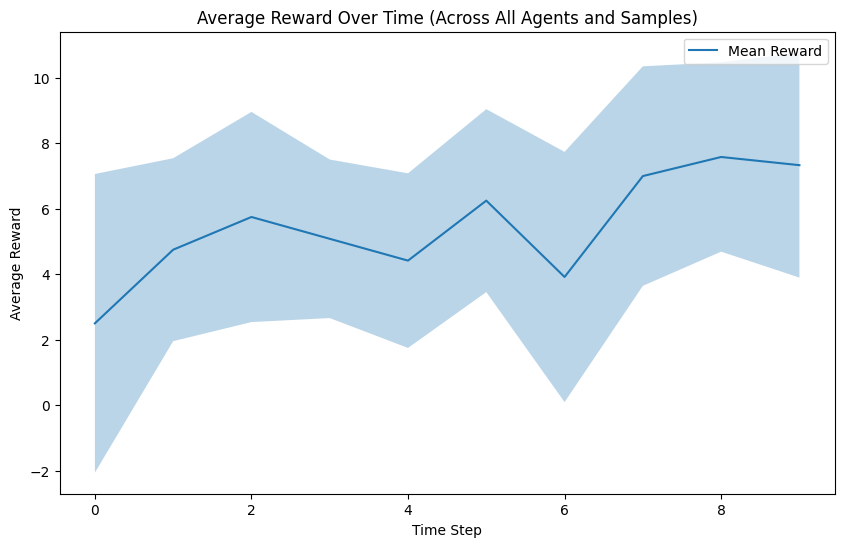

In [6]:
plot_avg_reward(gpt3_vs_random_reward_histories)

# GPT 3.5 vs GPT 4

# GPT 4 vs GPT 4